# L2 matchups with PACE data -- RRS

* Create a plan for files to use `pc.plan()`
* Print the plan to check it `print(plan.summary())`
* Do the plan and get matchups `pc.matchup(plan)`

## Prerequisite -- Login to EarthData

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [5]:
import earthaccess
earthaccess.login()

In [6]:
import earthaccess
results = earthaccess.search_datasets(instrument="oci")

short_names = [
    item.summary()["short-name"]
    for item in results
    if "L2" in item.summary()["short-name"]
]

print(short_names)

['PACE_OCI_L2_UVAI_UAA_NRT', 'PACE_OCI_L2_UVAI_UAA', 'PACE_OCI_L2_AER_UAA_NRT', 'PACE_OCI_L2_AER_UAA', 'PACE_OCI_L2_AOP_NRT', 'PACE_OCI_L2_AOP', 'PACE_OCI_L2_CLOUD_MASK_NRT', 'PACE_OCI_L2_CLOUD_MASK', 'PACE_OCI_L2_CLOUD_NRT', 'PACE_OCI_L2_CLOUD', 'PACE_OCI_L2_LANDVI_NRT', 'PACE_OCI_L2_LANDVI', 'PACE_OCI_L2_BGC_NRT', 'PACE_OCI_L2_BGC', 'PACE_OCI_L2_IOP_NRT', 'PACE_OCI_L2_IOP', 'PACE_OCI_L2_PAR_NRT', 'PACE_OCI_L2_PAR', 'PACE_OCI_L2_SFREFL_NRT', 'PACE_OCI_L2_SFREFL', 'PACE_OCI_L2_TRGAS_NRT', 'PACE_OCI_L2_TRGAS']


In [27]:
# bounding_box = (lon_min, lat_min, lon_max, lat_max)
import earthaccess
results = earthaccess.search_data(
    short_name = 'PACE_OCI_L2_AOP',
    temporal = ("2024-06-13", "2024-10-25"),
    bounding_box = (26.5, -82.8, 27.4, -82.5)
)
len(results)

329

## Load some points

In [4]:
from pathlib import Path
import earthaccess
import point_collocation as pc
import pandas as pd

HERE = Path.cwd()
POINTS_CSV = HERE / "fixtures" / "points.csv"
df_points = pd.read_csv(POINTS_CSV)  # lat, lon, date columns
print(len(df_points))
df_points.head()

595


,lat,lon,date
0,27.3835,-82.7375,2024-06-13
1,27.1190,-82.7125,2024-06-14
2,26.9435,-82.8170,2024-06-14
3,26.6875,-82.8065,2024-06-14
4,26.6675,-82.6455,2024-06-14


In [26]:
df_points.lon.min()

np.float64(-97.243)

## Get a plan for matchups from PACE data

In [33]:
%%time
# bounding_box = (lon_min, lat_min, lon_max, lat_max)
import point_collocation as pc
plan = pc.plan(
    df_points[0:100],
    data_source="earthaccess",
    source_kwargs={
        "short_name": "PACE_OCI_L2_AOP",
        "bounding_box": (-97.3, 24.6, -81.5, 30.39)
    },
    time_buffer="12h"
)

CPU times: user 22.2 s, sys: 150 ms, total: 22.3 s
Wall time: 39.8 s


In [34]:
plan.summary()

Plan: 100 points → 66 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 100
  Time buffer: 0 days 12:00:00

First 5 point(s):
  [0] lat=27.3835, lon=-82.7375, time=2024-06-13 12:00:00: 7 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T004810.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T005310.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T171620.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T184939.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T185439.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T234436.L2.OC_AOP.V3_1.nc
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613T2

## Get the matchups using that plan

In [3]:
res = pc.matchup(plan, variables=["Rrs"])

In [8]:
res

,lat,lon,time,granule_id,Rrs_346,Rrs_348,Rrs_351,Rrs_353,Rrs_356,Rrs_358,...,Rrs_706,Rrs_707,Rrs_708,Rrs_709,Rrs_711,Rrs_712,Rrs_713,Rrs_714,Rrs_717,Rrs_719
0,27.3835,-82.7375,2024-06-13 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27.1190,-82.7125,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26.9435,-82.8170,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26.6875,-82.8065,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26.6675,-82.6455,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,26.8985,-82.6710,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,26.8965,-82.5660,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,26.8925,-82.4220,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,26.7135,-82.4535,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,26.5020,-82.3010,2024-06-14 12:00:00,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## How long does it take?

In [8]:
%%time
import point_collocation as pc
plan = pc.plan(
    df_points[0:5],
    data_source="earthaccess",
    source_kwargs={
        "short_name": "PACE_OCI_L3M_RRS",
        "granule_name": "*.DAY.*.4km.*",
    }
)
res = pc.matchup(plan, variables=["Rrs"],)

CPU times: user 150 ms, sys: 38.5 ms, total: 189 ms
Wall time: 8.18 s


In [14]:
plan.summary()

Plan: 5 points → 2 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Variables  : ['avw']
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [0] lat=27.3835, lon=-82.7375, time=2024-06-13 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240613.L3m.DAY.AVW.V3_1.avw.4km.nc
  [1] lat=27.1190, lon=-82.7125, time=2024-06-14 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240614.L3m.DAY.AVW.V3_1.avw.4km.nc
  [2] lat=26.9435, lon=-82.8170, time=2024-06-14 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240614.L3m.DAY.AVW.V3_1.avw.4km.nc
  [3] lat=26.6875, lon=-82.8065, time=2024-06-14 12:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240614.L3m.DAY.AVW.V3_1.avw.4km.nc
  [4] lat=26.6675, lon=-82.6455, time=2024-06-14 12:00:00: 1 match(es)
    → h

<Axes: >

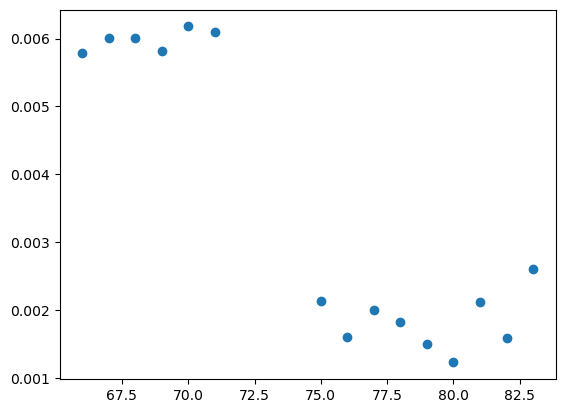

In [11]:
res.Rrs_346.plot(marker="o", linestyle="")